# config

/var/folders/4d/gg_x7bzj2kx7ln44mdwqlw480000gn/T/ipykernel_22291/1886080107.py:140: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", max(len(unique_labels), 1))


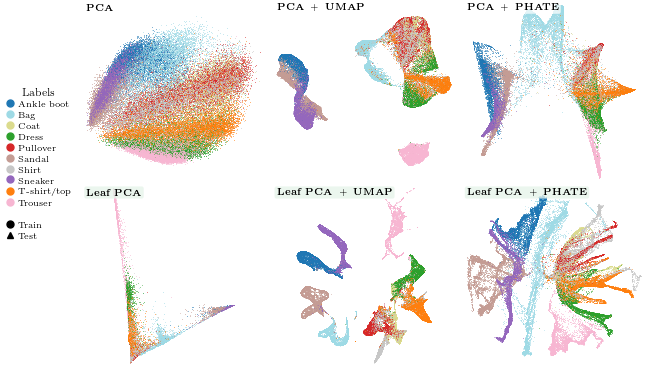

In [38]:
import re
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


# =============================================================================
# Global parameters
# =============================================================================

# LEAF_RESULTS_DIR = Path("/Users/aumona/Projects/RF-GAP-Python/experiments/results/20260413_220048_leaf_embedding_experiments_sign")
LEAF_RESULTS_DIR = Path("/Users/aumona/Projects/RF-GAP-Python/experiments/results/20260413_220850_leaf_embedding_experiments_fashion")
# LEAF_RESULTS_DIR = Path("/Users/aumona/Projects/RF-GAP-Python/experiments/results/20260413_221847_leaf_embedding_experiments_covtype")



# Sign MNIST SEED 44, KNN=50 for PHATE is good.
PLOT_DATASET = "fashion_mnist"  # "celegans", "pbmc", "sign_mnist", "tissuemnist_28", "fashion_mnist", 'covertype'
# PLOT_DATASET = "covertype"  # "celegans", "pbmc", "sign_mnist", "tissuemnist_28", "fashion_mnist", 'covertype'
# PLOT_DATASET = "sign_mnist"  # "celegans", "pbmc", "sign_mnist", "tissuemnist_28", "fashion_mnist", 'covertype'

PLOT_SEED = 44  # 578, 9, 912, 345, 44

TRAIN_MARKER = "o"
TEST_MARKER = "^"
POINT_SIZE = 0.3
POINT_ALPHA_TRAIN = 0.75
POINT_ALPHA_TEST = 0.95

# Match paper text width
TEXT_WIDTH_PT = 492.0
PT_TO_IN = 1.0 / 72.27
FIG_WIDTH = TEXT_WIDTH_PT * PT_TO_IN

# More room on the left for the label legend column
LEFT = 0.17
RIGHT = 0.995
BOTTOM = 0.08
TOP = 0.84
WSPACE = 0.05
HSPACE = 0.02



SUBPLOT_MARKERS = ["(a)", "(b)", "(c)", "(d)", "(e)", "(f)"]

TEXT_FONTSIZE = 6.6
TITLE_FONTSIZE = 7.8
LEGEND_FONTSIZE = 6.3

# Labels legend position (x-coordinate in figure fraction)
X_LABEL_LEGEND = 0.05

SHOW_SPLIT_MARKER_LEGEND = True
SPLIT_LEGEND_LOC = "lower left"

OUT_STEM = f"{PLOT_DATASET}_seed{PLOT_SEED}_embedding_grid_raw_vs_leaf"

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "font.size": 7.5,
    "axes.labelsize": 8,
    "axes.titlesize": TITLE_FONTSIZE,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": LEGEND_FONTSIZE,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.01,
})


# =============================================================================
# Helpers
# =============================================================================

def clean_display_title(title: str) -> str:
    title = title.replace("Raw ", "")
    title = re.sub(r"PCA\d+\s*\+\s*UMAP", "PCA + UMAP", title)
    title = re.sub(r"PCA\d+\s*\+\s*PHATE", "PCA + PHATE", title)
    return title

def format_runtime_seconds(x: float) -> str:
    if pd.isna(x):
        return "nan s"
    if x < 1:
        return f"{x:.2f} s"
    if x < 60:
        return f"{x:.1f} s"
    m = int(x // 60)
    s = x - 60 * m
    return f"{m}m {s:.0f}s"


def load_method_row(results_df: pd.DataFrame, dataset: str, seed: int, method_name: str) -> pd.Series:
    match = results_df[
        (results_df["dataset"] == dataset)
        & (results_df["seed"] == seed)
        & (results_df["method_name"] == method_name)
    ].copy()

    if len(match) == 0:
        raise ValueError(
            f"No row found for dataset={dataset}, seed={seed}, method_name={method_name}."
        )
    if len(match) > 1:
        raise ValueError(
            f"Multiple rows found for dataset={dataset}, seed={seed}, method_name={method_name}."
        )
    return match.iloc[0]


def load_embedding_pair(emb_dir: Path, dataset: str, seed: int, train_file: str, test_file: str):
    seed_dir = emb_dir / dataset / f"seed_{seed}"
    train_path = seed_dir / train_file
    test_path = seed_dir / test_file

    if not train_path.exists():
        raise FileNotFoundError(f"Missing train embedding file: {train_path}")
    if not test_path.exists():
        raise FileNotFoundError(f"Missing test embedding file: {test_path}")

    df_train = pd.read_csv(train_path)
    df_test = pd.read_csv(test_path)

    required_cols = {"label", "x1", "x2"}
    if not required_cols.issubset(df_train.columns):
        raise ValueError(f"{train_path.name} must contain columns {required_cols}")
    if not required_cols.issubset(df_test.columns):
        raise ValueError(f"{test_path.name} must contain columns {required_cols}")

    return df_train, df_test


def build_label_color_map(all_labels):
    unique_labels = pd.Index(pd.unique(pd.Series(all_labels))).tolist()
    cmap = plt.cm.get_cmap("tab20", max(len(unique_labels), 1))
    return {lab: cmap(i) for i, lab in enumerate(unique_labels)}


def detect_method_specs(results_df: pd.DataFrame, dataset: str, seed: int):
    subset = results_df[
        (results_df["dataset"] == dataset)
        & (results_df["seed"] == seed)
    ].copy()

    available_methods = set(subset["method_name"].unique())

    required_fixed = {"raw_pca", "leaf_pca"}
    missing_fixed = sorted(required_fixed - available_methods)
    if missing_fixed:
        raise ValueError(
            f"Missing required methods for dataset={dataset}, seed={seed}: {missing_fixed}"
        )

    raw_pca_umap_methods = sorted(
        [m for m in available_methods if re.fullmatch(r"raw_pca\d+_umap", str(m))],
        key=lambda s: int(re.search(r"\d+", s).group())
    )
    leaf_pca_umap_methods = sorted(
        [m for m in available_methods if re.fullmatch(r"leaf_pca\d+_umap", str(m))],
        key=lambda s: int(re.search(r"\d+", s).group())
    )
    raw_pca_phate_methods = sorted(
        [m for m in available_methods if re.fullmatch(r"raw_pca\d+_phate", str(m))],
        key=lambda s: int(re.search(r"\d+", s).group())
    )
    leaf_pca_phate_methods = sorted(
        [m for m in available_methods if re.fullmatch(r"leaf_pca\d+_phate", str(m))],
        key=lambda s: int(re.search(r"\d+", s).group())
    )

    if len(raw_pca_umap_methods) == 0:
        raise ValueError(f"No raw_pca*_umap method found for dataset={dataset}, seed={seed}.")
    if len(leaf_pca_umap_methods) == 0:
        raise ValueError(f"No leaf_pca*_umap method found for dataset={dataset}, seed={seed}.")
    if len(raw_pca_phate_methods) == 0:
        raise ValueError(f"No raw_pca*_phate method found for dataset={dataset}, seed={seed}.")
    if len(leaf_pca_phate_methods) == 0:
        raise ValueError(f"No leaf_pca*_phate method found for dataset={dataset}, seed={seed}.")

    raw_pca_umap_method = raw_pca_umap_methods[-1]
    leaf_pca_umap_method = leaf_pca_umap_methods[-1]
    raw_pca_phate_method = raw_pca_phate_methods[-1]
    leaf_pca_phate_method = leaf_pca_phate_methods[-1]

    raw_pca_umap_k = int(re.search(r"raw_pca(\d+)_umap", raw_pca_umap_method).group(1))
    leaf_pca_umap_k = int(re.search(r"leaf_pca(\d+)_umap", leaf_pca_umap_method).group(1))
    raw_pca_phate_k = int(re.search(r"raw_pca(\d+)_phate", raw_pca_phate_method).group(1))
    leaf_pca_phate_k = int(re.search(r"leaf_pca(\d+)_phate", leaf_pca_phate_method).group(1))

    return [
        {
            "method_name": "raw_pca",
            "title": "Raw PCA",
            "train_file": "raw_pca_train.csv",
            "test_file": "raw_pca_test.csv",
            "row": 0,
            "col": 0,
        },
        {
            "method_name": raw_pca_umap_method,
            "title": f"Raw PCA{raw_pca_umap_k} + UMAP",
            "train_file": f"raw_pca{raw_pca_umap_k}_umap_train.csv",
            "test_file": f"raw_pca{raw_pca_umap_k}_umap_test.csv",
            "row": 0,
            "col": 1,
        },
        {
            "method_name": raw_pca_phate_method,
            "title": f"Raw PCA{raw_pca_phate_k} + PHATE",
            "train_file": f"raw_pca{raw_pca_phate_k}_phate_train.csv",
            "test_file": f"raw_pca{raw_pca_phate_k}_phate_test.csv",
            "row": 0,
            "col": 2,
        },
        {
            "method_name": "leaf_pca",
            "title": "Leaf PCA",
            "train_file": "leaf_pca_train.csv",
            "test_file": "leaf_pca_test.csv",
            "row": 1,
            "col": 0,
        },
        {
            "method_name": leaf_pca_umap_method,
            "title": f"Leaf PCA{leaf_pca_umap_k} + UMAP",
            "train_file": f"leaf_pca{leaf_pca_umap_k}_umap_train.csv",
            "test_file": f"leaf_pca{leaf_pca_umap_k}_umap_test.csv",
            "row": 1,
            "col": 1,
        },
        {
            "method_name": leaf_pca_phate_method,
            "title": f"Leaf PCA{leaf_pca_phate_k} + PHATE",
            "train_file": f"leaf_pca{leaf_pca_phate_k}_phate_train.csv",
            "test_file": f"leaf_pca{leaf_pca_phate_k}_phate_test.csv",
            "row": 1,
            "col": 2,
        },
    ]


def set_square_limits(ax, x_all, y_all, pad_frac=0.04):
    x_min, x_max = x_all.min(), x_all.max()
    y_min, y_max = y_all.min(), y_all.max()

    x_mid = 0.5 * (x_min + x_max)
    y_mid = 0.5 * (y_min + y_max)

    half_range = max(x_max - x_min, y_max - y_min) * 0.5
    half_range *= (1 + pad_frac)

    ax.set_xlim(x_mid - half_range, x_mid + half_range)
    ax.set_ylim(y_mid - half_range, y_mid + half_range)
    ax.set_aspect("equal", adjustable="box")


# =============================================================================
# Load run outputs
# =============================================================================

results_csv = LEAF_RESULTS_DIR / "embedding_runtime_results.csv"
emb_dir = LEAF_RESULTS_DIR / "embeddings"

if not results_csv.exists():
    raise FileNotFoundError(f"Could not find results CSV: {results_csv}")
if not emb_dir.exists():
    raise FileNotFoundError(f"Could not find embeddings directory: {emb_dir}")

results_df = pd.read_csv(results_csv)
method_specs = detect_method_specs(results_df, PLOT_DATASET, PLOT_SEED)

all_labels = []
loaded = []

for spec in method_specs:
    row = load_method_row(results_df, PLOT_DATASET, PLOT_SEED, spec["method_name"])
    df_train, df_test = load_embedding_pair(
        emb_dir=emb_dir,
        dataset=PLOT_DATASET,
        seed=PLOT_SEED,
        train_file=spec["train_file"],
        test_file=spec["test_file"],
    )
    all_labels.extend(df_train["label"].tolist())
    all_labels.extend(df_test["label"].tolist())
    loaded.append((spec, row, df_train, df_test))

label_to_color = build_label_color_map(all_labels)


# =============================================================================
# Figure geometry
# =============================================================================

nrows = 2
ncols = 3
usable_width = FIG_WIDTH * (RIGHT - LEFT)
axes_width = usable_width / (ncols + (ncols - 1) * WSPACE)
fig_height = (nrows * axes_width + (nrows - 1) * HSPACE * axes_width) / (TOP - BOTTOM)

fig, axes = plt.subplots(nrows, ncols, figsize=(FIG_WIDTH, fig_height), squeeze=False)
fig.subplots_adjust(
    left=LEFT,
    right=RIGHT,
    bottom=BOTTOM,
    top=TOP,
    wspace=WSPACE,
    hspace=HSPACE,
)


# =============================================================================
# Plot
# =============================================================================

for spec, row, df_train, df_test in loaded:
    ax = axes[spec["row"], spec["col"]]

    for lab, grp in df_train.groupby("label"):
        ax.scatter(
            grp["x1"],
            grp["x2"],
            s=POINT_SIZE,
            c=[label_to_color[lab]],
            marker=TRAIN_MARKER,
            alpha=POINT_ALPHA_TRAIN,
            linewidths=0,
            rasterized=True,
        )

    for lab, grp in df_test.groupby("label"):
        ax.scatter(
            grp["x1"],
            grp["x2"],
            s=POINT_SIZE,
            c=[label_to_color[lab]],
            marker=TEST_MARKER,
            alpha=POINT_ALPHA_TEST,
            linewidths=0,
            rasterized=True,
        )

    xy_all = pd.concat(
        [df_train[["x1", "x2"]], df_test[["x1", "x2"]]],
        axis=0,
        ignore_index=True,
    )
    set_square_limits(ax, xy_all["x1"].to_numpy(), xy_all["x2"].to_numpy(), pad_frac=0.04)

    knn_acc = row["knn_test_acc_avg"]
    runtime = row["train_total_time_s"] + row["test_total_time_s"]
    
    display_title = clean_display_title(spec["title"])
    is_leaf_method = spec["method_name"].startswith("leaf_")
    
    box_facecolor = "#e6f4ea" if is_leaf_method else "white"
    box_alpha = 0.78 if is_leaf_method else 0.72
    
    ax.text(
        0.02,
        0.98,
        r"$\bf{" + display_title.replace(" ", r"\ ") + "}$"
        # + "\n"
        # + rf"$k$NN acc: {knn_acc:.3f}"
        # + "\n"
        # + f"Time: {format_runtime_seconds(runtime)}"
        ,
        transform=ax.transAxes,
        ha="left",
        va="top",
        multialignment="left",
        fontsize=TEXT_FONTSIZE,
        bbox=dict(
            boxstyle="round,pad=0.22",
            facecolor=box_facecolor,
            alpha=box_alpha,
            edgecolor="none",
        ),
    )

    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)


label_handles = [
    Line2D(
        [0], [0],
        marker="o",
        color=label_to_color[lab],
        linestyle="None",
        markersize=5,
        label=str(lab),
    )
    for lab in sorted(label_to_color.keys(), key=lambda x: str(x))
]

combined_handles = list(label_handles)
combined_labels = [h.get_label() for h in label_handles]

if SHOW_SPLIT_MARKER_LEGEND:
    combined_handles.extend([
        Line2D([], [], linestyle="None", marker=None, color="none", label=""),
        Line2D(
            [0], [0],
            marker=TRAIN_MARKER,
            color="black",
            linestyle="None",
            markersize=5,
            label="Train",
        ),
        Line2D(
            [0], [0],
            marker=TEST_MARKER,
            color="black",
            linestyle="None",
            markersize=5,
            label="Test",
        ),
    ])
    combined_labels.extend(["", "Train", "Test"])

left_legend = fig.legend(
    handles=combined_handles,
    labels=combined_labels,
    loc="center left",
    bbox_to_anchor=(X_LABEL_LEGEND, 0.50),
    bbox_transform=fig.transFigure,
    ncol=1,
    frameon=False,
    title="Labels",
    borderaxespad=0.0,
    handletextpad=0.4,
    labelspacing=0.35,
    columnspacing=0.6,
    handlelength=1.2,
)

# Output directory
OUT_DIR = Path("/Users/aumona/Projects/RF-GAP-Python/experiments/notebooks/compiled_embedding_figure")
OUT_DIR.mkdir(parents=True, exist_ok=True)

out_base = OUT_DIR / OUT_STEM

fig.savefig(out_base.with_suffix(".pdf"), bbox_extra_artists=[left_legend])
fig.savefig(out_base.with_suffix(".png"), dpi=300, bbox_extra_artists=[left_legend])

plt.show()